# NEID Data Tutorial

This tutorial demonstrates how to create and use RVData standard files for the NEID instrument at all data levels:

- **Level 2 (L2)**: Extracted, wavelength-calibrated echelle spectra
- **Level 3 (L3)**: Stitched 1D spectrum on a common wavelength grid
- **Level 4 (L4)**: Radial velocity measurements

## Prerequisites

Install the rvdata package:
```bash
pip install rv-data-standard
```

## Setup and Data Download

First, we'll import the necessary modules and download sample NEID data files.

In [1]:
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

# RVData imports
from rvdata.core.models.level2 import RV2
from rvdata.core.models.level3 import RV3
from rvdata.core.models.level4 import RV4

In [2]:
def download_file(url, filename):
    """Download a file if it doesn't already exist."""
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        response = requests.get(url)
        response.raise_for_status()
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Downloaded {filename}")
    else:
        print(f"{filename} already exists, skipping download.")

# NEID sample data URLs (hosted on project server)
# Native NEID L2 file is needed to create L2
# Native NEID L2 file is needed to create L4
file_urls = {
    "native_l2": "http://grinnell.as.arizona.edu/~rvdata/neid/neidL2_20231010T020006.fits",
}

# Download the files
native_l2_file = "neidL2_20231010T020006.fits"

download_file(file_urls["native_l2"], native_l2_file)

Downloaded neidL2_20231010T020006.fits


---
# Level 2: Extracted Echelle Spectra

Level 2 data contains wavelength-calibrated, extracted echelle spectra organized by trace (fiber). Each trace contains flux, wavelength, variance, and blaze function arrays.

## Creating L2 from Native NEID Files

For a RVData-standard L2 file only the native L2 NEID data file is needed `neidL2_YYYYMMDDTHHMMSS.fits`

In [3]:
# Create RVData-standard L2 from native NEID files
neid_l2 = RV2.from_fits(native_l2_file, instrument="NEID")

# Save to FITS file
l2_standard_file = neid_l2.to_fits()
print(f"Created {l2_standard_file}")

Created neid_SL2_20231010T020006.fits


## Using L2 Data

### Reading the L2 File

You can read L2 files using either astropy's `fits.open()` or the RVData `RV2.from_fits()` method.

In [4]:
# Open using astropy
l2 = fits.open(l2_standard_file)

# Examine the primary header - same keywords regardless of instrument!
hdr = l2[0].header
print(f"Telescope: {hdr['TELESCOP']}")
print(f"Instrument: {hdr['INSTRUME']}")
print(f"Object: {hdr['OBJECT']}")
print(f"Number of traces: {hdr['NUMTRACE']}")
print("\nTrace contents:")
for i in range(1, hdr['NUMTRACE'] + 1):
    print(f"  TRACE{i}: {hdr[f'TRACE{i}']}")

Telescope: WIYN 3.5m
Instrument: NEID
Object: HD 185144
Number of traces: 3

Trace contents:
  TRACE1: Gaia DR2 2261614264930275072
  TRACE2: Sky
  TRACE3: Etalon


### Examining L2 Extensions

The `EXT_DESCRIPT` extension lists all FITS extensions in the file.

In [5]:
# List all extensions
ext_descript = Table.read(l2, hdu='EXT_DESCRIPT')
ext_descript[['Name', 'Description']].pprint_all()

       Name                                          Description                                   
----------------- ---------------------------------------------------------------------------------
          PRIMARY                                               EPRV Standard FITS HEADER (no data)
INSTRUMENT_HEADER                                     Primary header of native NEID instrument file
          RECEIPT                                     The list of operations performed on this file
       DRP_CONFIG                             Pipeline details to go from the raw file to this file
     EXT_DESCRIPT                        Contains the description of all the extensions in the file
      ORDER_TABLE                                                Table of echelle order information
      TRACE1_FLUX                                                 Flux in Trace 1 NEID HR SCI fiber
      TRACE1_WAVE                                           Wavelength in Trace 1 NEID HR SCI fiber


### Examining the Order Table

The `ORDER_TABLE` extension describes the wavelength coverage of each echelle order.

In [6]:
order_table = Table.read(l2_standard_file,hdu="ORDER_TABLE")
order_table['wave_start'][order_table['wave_start'] == 0.] = np.nan
order_table['wave_end'][order_table['wave_end'] == 0.] = np.nan
print(f"Number of orders: {len(order_table)}")
print(f"\nWavelength coverage: {np.nanmin(order_table['wave_start']):.1f} - {np.nanmax(order_table['wave_end']):.1f} Angstroms")
print("\nFirst 5 orders:")
print(order_table[:5])
print("\nLast 5 orders:")
print(order_table[-5:])

Number of orders: 122

Wavelength coverage: 3570.9 - 11251.2 Angstroms

First 5 orders:
echelle_order order_index     wave_start         wave_end    
------------- ----------- ----------------- -----------------
          173           0               nan               nan
          172           1               nan               nan
          171           2               nan               nan
          170           3  3570.93576756872 3640.056733452913
          169           4 3591.935420310261 3661.512783703846

Last 5 orders:
echelle_order order_index     wave_start          wave_end     
------------- ----------- ------------------ ------------------
           56         117 10821.217523481686 11045.807518650605
           55         118 11038.908724195322 11251.197788845078
           54         119                nan                nan
           53         120                nan                nan
           52         121                nan                nan


### Plotting L2 Spectra

NEID has 3 traces in High Resolution mode (HR):
- TRACE1: Science fiber
- TRACE2: Calibration fiber (etalon)
- TRACE3: Sky fiber

Let's plot one order from the science traces.

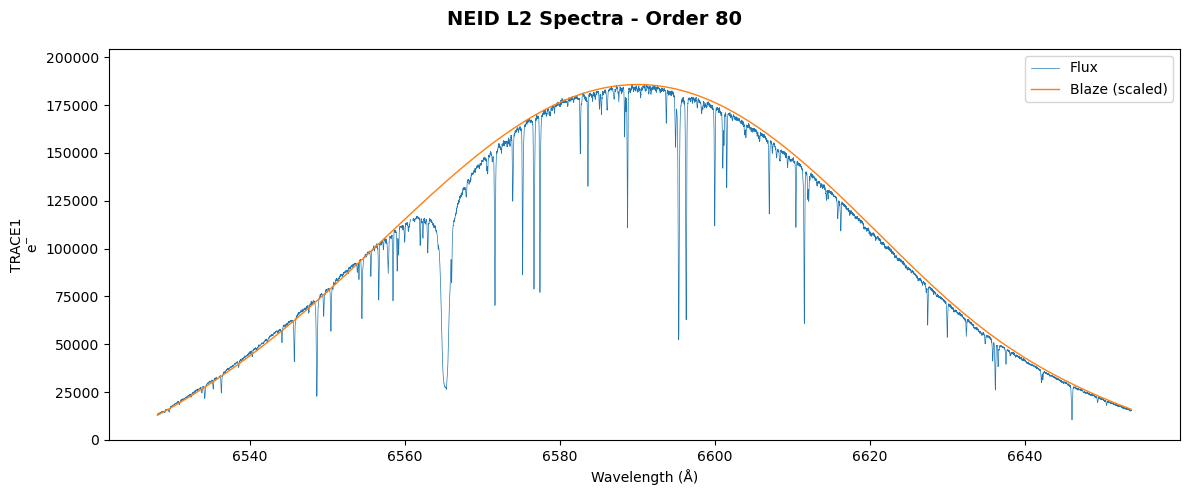

In [7]:
# Plot a single order from the three science traces
order = 80  # Choose an order to plot

fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
trace_num = 1
wave = l2[f'TRACE{trace_num}_WAVE'].data[order]
flux = l2[f'TRACE{trace_num}_FLUX'].data[order]
blaze = l2[f'TRACE{trace_num}_BLAZE'].data[order]

# Scale blaze for visualization
blaze_scaled = blaze * (np.nanmax(flux) / np.nanmax(blaze))

ax.plot(wave, flux, color='tab:blue', linestyle='-', lw=0.5, label='Flux')
ax.plot(wave, blaze_scaled, color='tab:orange', linestyle='-', lw=1, label='Blaze (scaled)')
ax.set_ylabel(f'TRACE{trace_num}'+'\ne$^{-}$')
ax.legend(loc='upper right')
ax.set_ylim(0, np.nanmax(flux) * 1.1)

ax.set_xlabel('Wavelength (\u212B)')
fig.suptitle(f'NEID L2 Spectra - Order {order}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Level 3: Stitched 1D Spectrum

Level 3 data contains a stitched 1D spectrum on a common wavelength grid with constant velocity spacing. The stitching process:
1. Divides out the blaze function
2. Resamples each order onto a common wavelength grid
3. Combines overlapping regions using inverse-variance weighting

## Creating L3 from L2

L3 is created from an RVData-standard L2 file.

In [8]:
# Create L3 from the standard L2 file
neid_l2 = RV2.from_fits(l2_standard_file)
neid_l3 = RV3()
neid_l3.convert_level2_to_level3(neid_l2)
# Save to FITS file
l3_standard_file = neid_l3.to_fits()
print(f"Created {l3_standard_file}")

Created neid_SL3_20231010T020006.fits


## Using L3 Data

### Reading the L3 File

In [9]:
# Open the L3 file
l3 = fits.open(l3_standard_file)

# List extensions
print("L3 Extensions:")
for hdu in l3:
    print(f"  {hdu.name}")

L3 Extensions:
  PRIMARY
  INSTRUMENT_HEADER
  RECEIPT
  DRP_CONFIG
  EXT_DESCRIPT
  ORDER_TABLE
  STITCHED_CORR_SCI_FLUX
  STITCHED_CORR_SCI_WAVE
  STITCHED_CORR_SCI_VAR


### Understanding L3 Extensions

For NEID with one science fiber, the stitched spectrum is stored are in `STITCHED_CORR_SCI_*` extensions:
- `STITCHED_CORR_SCI_WAVE/FLUX/VAR`: Science fiber

In [10]:
# Check which STITCHED extensions are present
stitched_exts = [hdu.name for hdu in l3 if 'STITCHED' in hdu.name]
print("Stitched spectrum extensions:")
for ext in stitched_exts:
    print(f"  {ext}")

Stitched spectrum extensions:
  STITCHED_CORR_SCI_FLUX
  STITCHED_CORR_SCI_WAVE
  STITCHED_CORR_SCI_VAR


### Plotting the Stitched Spectrum

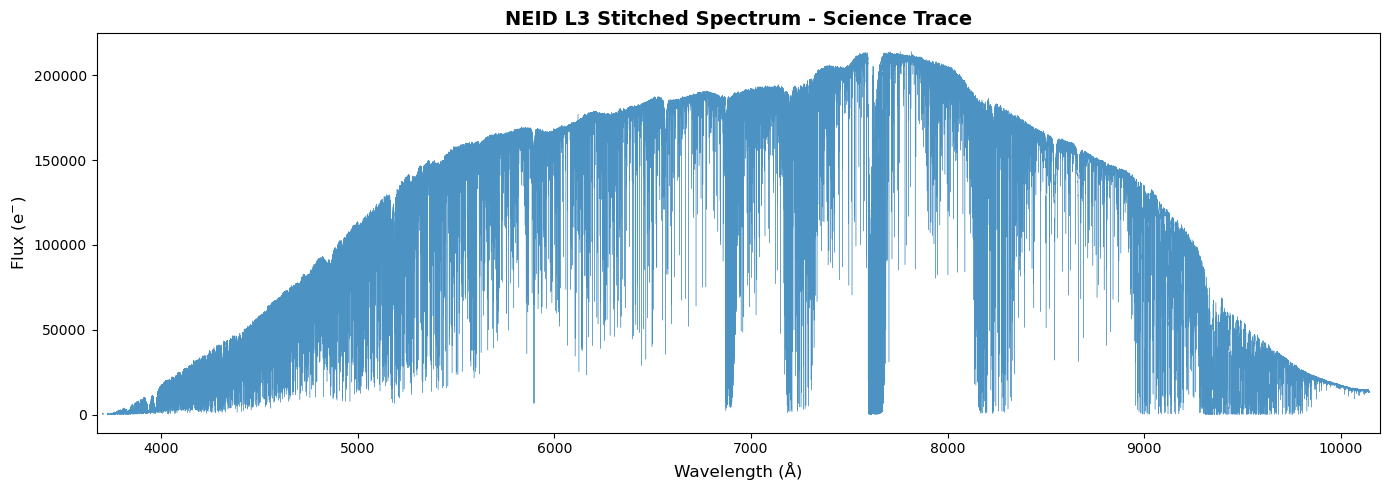


Wavelength range: 3670.0 - 10200.0 Angstroms
Number of pixels: 493473


In [11]:
# Plot the stitched spectrum for one trace
wave_ext = "STITCHED_CORR_SCI_WAVE"
flux_ext = "STITCHED_CORR_SCI_FLUX"
wave_l3 = l3[wave_ext].data
flux_l3 = l3[flux_ext].data

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(wave_l3, flux_l3, color='tab:blue', linestyle='-', lw=0.3, alpha=0.8)
ax.set_xlabel('Wavelength (\u212B)', fontsize=12)
ax.set_ylabel('Flux (e$^{-}$)', fontsize=12)
ax.set_title(f'NEID L3 Stitched Spectrum - Science Trace', fontsize=14, fontweight='bold')

# Zoom inset
ax.set_xlim(wave_l3[np.isfinite(wave_l3)].min(), wave_l3[np.isfinite(wave_l3)].max())
plt.tight_layout()
plt.show()

print(f"\nWavelength range: {np.nanmin(wave_l3):.1f} - {np.nanmax(wave_l3):.1f} Angstroms")
print(f"Number of pixels: {len(wave_l3)}")


### Zoomed View of Spectral Features

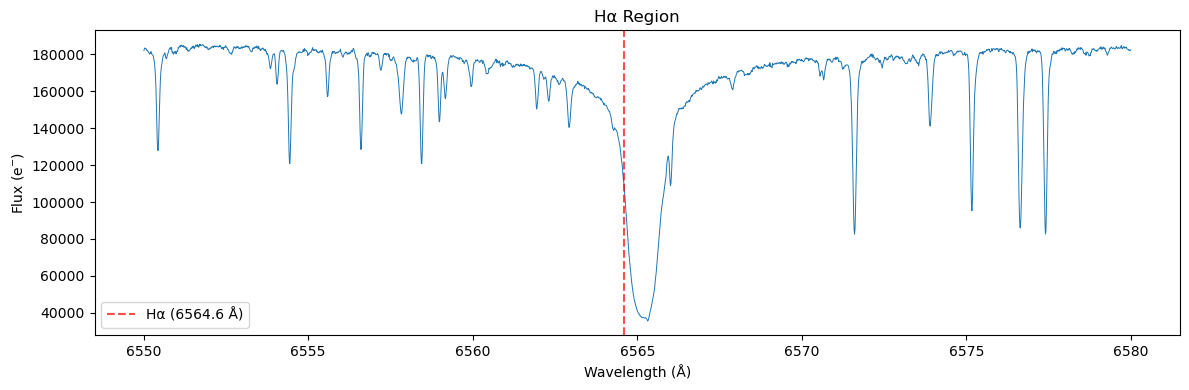

In [12]:
# Zoom in on H-alpha region
if wave_ext in [hdu.name for hdu in l3]:
    fig, ax = plt.subplots(figsize=(12, 4))
    
    # H-alpha region
    mask = (wave_l3 > 6550) & (wave_l3 < 6580)
    ax.plot(wave_l3[mask], flux_l3[mask], color='tab:blue', linestyle='-', lw=0.7)
    ax.axvline(6564.6, color='red', ls='--', alpha=0.7, label='H\u03B1 (6564.6 \u212B)')
    ax.set_xlabel('Wavelength (\u212B)')
    ax.set_ylabel('Flux (e$^{-}$)')
    ax.set_title('H\u03B1 Region', fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
# Level 4: Radial Velocity Measurements

Level 4 data contains radial velocity (RV) measurements derived from the spectra. These can include:
- Per-order RVs
- Combined RV with uncertainty
- Activity indicators

## Creating L4 from Native NEID L2

L4 is typically created from native pipeline outputs that contain RV measurements. For NEID, the native L2 file includes CCF-derived RVs.

In [13]:
# Create L4 from native NEID L2 file (which contains RV measurements)
neid_l4 = RV4.from_fits(native_l2_file, instrument="NEID")

# Save to FITS file
l4_standard_file = neid_l4.to_fits()
print(f"Created {l4_standard_file}")

Created neid_SL4_20231010T020006.fits


## Using L4 Data

### Reading the L4 File

In [14]:
# Open the L4 file
l4 = fits.open(l4_standard_file)

# Examine primary header for RV info
hdr4 = l4[0].header
print(f"Object: {hdr4['OBJECT']}")
print(f"Observation time (BJD): {hdr4.get('BJDTDB', 'N/A')}")

# List extensions
print("\nL4 Extensions:")
for hdu in l4:
    print(f"  {hdu.name}")

Object: HD 185144
Observation time (BJD): 2460227.586673037

L4 Extensions:
  PRIMARY
  INSTRUMENT_HEADER
  RECEIPT
  DRP_CONFIG
  EXT_DESCRIPT
  RV1
  CCF1
  DIAGNOSTICS1


### Examining the RV Table

The `RV_TABLE` extension contains the radial velocity measurements.

In [15]:
# Check if RV_TABLE exists
if 'RV_TABLE' in [hdu.name for hdu in l4]:
    rv_table = Table(l4, hdu='RV_TABLE')
    print("RV Table columns:")
    print(rv_table.columns.tolist())
    print("\nRV Table:")
    print(rv_table)
else:
    print("RV_TABLE not found in this L4 file.")
    print("\nAvailable extensions:")
    for hdu in l4:
        if hdu.data is not None:
            print(f"  {hdu.name}: {type(hdu.data)}")

RV_TABLE not found in this L4 file.

Available extensions:
  INSTRUMENT_HEADER: <class 'numpy.ndarray'>
  RECEIPT: <class 'astropy.io.fits.fitsrec.FITS_rec'>
  DRP_CONFIG: <class 'astropy.io.fits.fitsrec.FITS_rec'>
  EXT_DESCRIPT: <class 'astropy.io.fits.fitsrec.FITS_rec'>
  RV1: <class 'astropy.io.fits.fitsrec.FITS_rec'>
  CCF1: <class 'numpy.ndarray'>
  DIAGNOSTICS1: <class 'astropy.io.fits.fitsrec.FITS_rec'>


### Per-Order RVs

L4 files may also contain per-order RV measurements in the `ORDER_RV` extension.

In [16]:
# Check for per-order RVs
if 'ORDER_RV' in [hdu.name for hdu in l4]:
    order_rv = l4['ORDER_RV'].data
    
    fig, ax = plt.subplots(figsize=(10, 5))
    orders = np.arange(len(order_rv))
    ax.scatter(orders, order_rv, s=20, alpha=0.7)
    ax.axhline(np.nanmedian(order_rv), color='red', ls='--', label=f'Median: {np.nanmedian(order_rv):.2f} m/s')
    ax.set_xlabel('Order Index')
    ax.set_ylabel('RV (m/s)')
    ax.set_title('Per-Order Radial Velocities')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("ORDER_RV extension not found.")

ORDER_RV extension not found.


---
# Summary

This tutorial demonstrated how to:

1. **Create L2** from native NEID L2 file using `RV2.from_fits()`
2. **Use L2** data: access headers, examine extensions, plot spectra
3. **Create L3** from standard L2 using `neid_l2 = RV2.from_fits()` and `RV3().convert_level2_to_level3(neid_l2)`
4. **Use L3** data: access stitched spectra, examine spectral features
5. **Create L4** from native NEID L2 using `RV4.from_fits()`
6. **Use L4** data: access RV measurements and per-order RVs

The standardized data format allows consistent access patterns across all EPRV instruments!

In [17]:
# Clean up - close FITS files
l2.close()
l3.close()
l4.close()